# Exploration Data Analysis - Khám phá dữ liệu
Trong notebooks này, chúng tôi sẽ tập trung tìm hiểu đặc điểm và xử lý tập dữ liệu `sales.csv` riêng:
- Kiểm tra tổng quan dữ liệu
- Kiểm tra tính toàn vẹn dữ liệu
- Xử lý, làm sạch dữ liệu
- Trực quan hóa dữ liệu

**Mục tiêu**: Xử lý, làm sạch và xác định rõ đặc điểm của tập dữ liệu `sales.csv` trước khi đi vào huấn luyện mô hình

**Mục lục**:
1. [Thiết lập và cài đặt](#1)
2. [Tổng quan dữ liệu](#2)
3. [Trực quan hóa dữ liệu](#3)

<a id="1"></a>

## 1. Thiết lập và cài đặt
Nhập các thư viện cần thiết và kết nối database `datathon.duckdb`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys, os

sys.path.append(os.path.abspath('..'))
from src.connection import get_connection

In [2]:
# Kiểm tra kết nối
conn = get_connection()

[OKE] Kết nối thành công tới database tại C:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\data\database\datathon.duckdb


In [3]:
sql = 'SELECT * FROM sales'
df_sales = conn.execute(sql).df()
df_sales.head()

,date,revenue,cogs
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 2. Đặc điểm dữ liệu

In [4]:
df_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     3833 non-null   datetime64[us]
 1   revenue  3833 non-null   float64       
 2   cogs     3833 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 90.0 KB


In [5]:
df_sales.describe()

,date,revenue,cogs
count,3833,3.833000e+03,3.833000e+03
mean,2017-10-02 00:00:00,4.286584e+06,3.695134e+06
min,2012-07-04 00:00:00,2.798139e+05,2.365763e+05
25%,2015-02-17 00:00:00,2.471089e+06,2.150580e+06
50%,2017-10-02 00:00:00,3.647304e+06,3.161113e+06
75%,2020-05-17 00:00:00,5.350877e+06,4.637294e+06
max,2022-12-31 00:00:00,2.090527e+07,1.653586e+07
std,NaN,2.624840e+06,2.219789e+06


In [6]:
print(f"Thời gian bắt đầu: {df_sales['date'][0]}")
print(f"Thời gian kết thúc: {df_sales['date'].iloc[-1]}")
print(f"Khoảng thời gian: {len(df_sales)} ngày")
print(f"Bước thời gian: {df_sales['date'][1] - df_sales['date'][0]}")

Thời gian bắt đầu: 2012-07-04 00:00:00
Thời gian kết thúc: 2022-12-31 00:00:00
Khoảng thời gian: 3833 ngày
Bước thời gian: 1 days 00:00:00


Như vậy, ta được biết một vài đặc điểm của dữ liệu ở bảng `sales` gồm có
- Cột `date` bắt đầu từ ngày **2012-07-04** -> **2022-12-31**
- Mỗi dòng là một ngày, tổng là 3833 ngày
- Cột `revenue`: thông tin và doanh thu của mỗi ngày
- Cột `cogs`: thông tin về giá vốn của ngày đó

Chính vì đây là bảng dữ liệu theo chuỗi thời gian, vì vậy việc trực quan hóa dữ liệu để thấy được tính chu kỳ là vô cùng cần thiết

## 3. Trực quan hóa dữ liệu

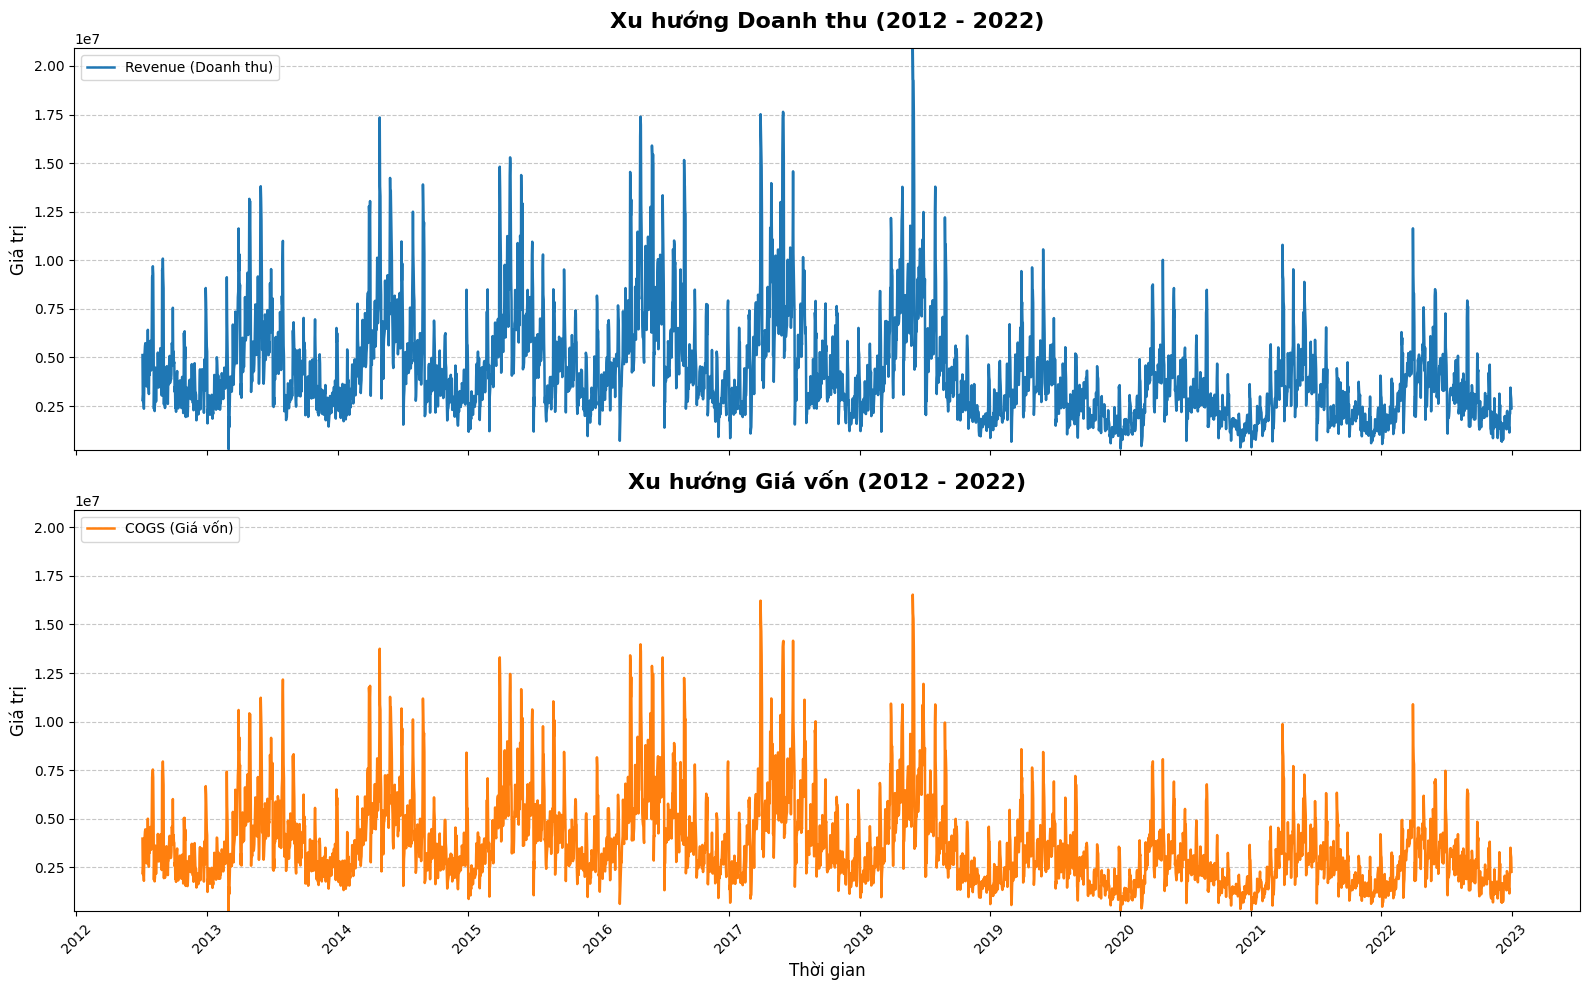

In [7]:
# Trực quan hóa dữ liệu theo chuỗi thời gian
# Xác định min/max chung cho trục Y
y_min = min(df_sales['revenue'].min(), df_sales['cogs'].min())
y_max = max(df_sales['revenue'].max(), df_sales['cogs'].max())
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# revenue
axes[0].plot(
    df_sales['date'],
    df_sales['revenue'],
    color='#1f77b4',
    linewidth=1.8,
    label='Revenue (Doanh thu)'
)

axes[0].set_title(
    'Xu hướng Doanh thu (2012 - 2022)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

axes[0].set_ylabel('Giá trị', fontsize=12)
axes[0].set_ylim(y_min, y_max)   # Trục Y giống nhau
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(loc='upper left')

# cogs
axes[1].plot(
    df_sales['date'],
    df_sales['cogs'],
    color='#ff7f0e',
    linewidth=1.8,
    label='COGS (Giá vốn)'
)

axes[1].set_title(
    'Xu hướng Giá vốn (2012 - 2022)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

axes[1].set_ylabel('Giá trị', fontsize=12)
axes[1].set_xlabel('Thời gian', fontsize=12)
axes[1].set_ylim(y_min, y_max)   # Trục Y giống nhau
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(loc='upper left')

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Qua biểu đồ ta có thể chắc chắn rằng dữ liệu có tính mùa vụ qua các năm, khi mà tầm giai đoạn từ đầu năm đến cuối năm doanh thu của doanh nghiệp đang được tăng mạnh, rồi từ giữa năm đến cuối năm thì doanh thu lại xuống dốc, và chu kỳ cứ lặp đi lặp lại. Ngoài ra trước 2019 doanh nghiệp lại có doanh thu rất cao, còn từ sau 2019 thì doanh thu đã giảm đi đáng kể.

Câu hỏi đặt ra là:
- Tại sao doanh thu của doanh nghiệp lại tăng cao vào giữa tháng ?
- Tại sao doanh thu lại thấp ở đầu năm và cuối năm ?
- Liệu doanh thu của doanh nghiệp còn chu kỳ ngắn không ?

Phần trăm độ tương quan (Pearson) = 97.60%


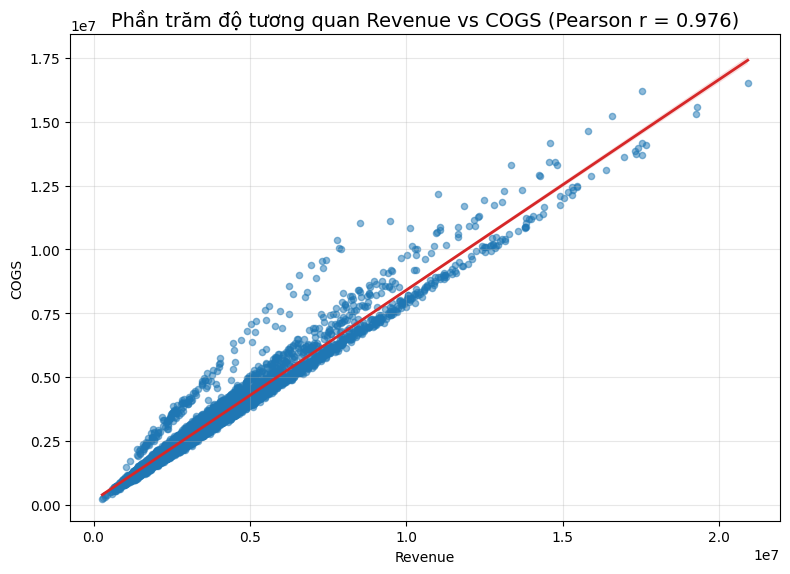

In [8]:
# Tương quan giữa revenue và cogs
corr_value = df_sales['revenue'].corr(df_sales['cogs'])
corr_percent = corr_value * 100
print(f'Phần trăm độ tương quan (Pearson) = {corr_percent:.2f}%')

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_sales,
    x='revenue',
    y='cogs',
    scatter_kws={'alpha': 0.5, 's': 20},
    line_kws={'color': '#d62728', 'linewidth': 2},
    ci=95,
    color='#1f77b4'
 )
plt.title(f'Phần trăm độ tương quan Revenue vs COGS (Pearson r = {corr_value:.3f})', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('COGS')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Do `cogs` và `revenue` đang có độ tương quan rất lớn, chúng ta có thể rút ra rằng việc các đợt doanh thu tăng cũng sẽ khiến cho giá vốn tăng, điều này khiến lợi nhuận mà doanh nghiệp thu lại đang chưa được tối ưu.

Ngoài ra, nếu chúng ta sử dụng cogs để cho vào mô hình sẽ khiến mô hình bị overfitting, vì vậy sau đó chúng tôi sẽ quyết định sẽ train mô hình với 2 dữ liệu là `revenue` và `cogs`, đặc biệt `revenue` sẽ được dùng để phân tích và cải thiện mô hình, còn `cogs` sẽ dựa vào đó cộng thêm ràng buộc là `revenue` > `cogs` để dự đoán

<a id='1'></a>

## 4. Tính chu kỳ
Sau khi quan sát, chúng tôi nhận thấy là từ 2012 đến 2018, doanh thu có xu hướng tăng qua các năm, nhưng qua 2019 thì doanh thu xụt giảm đi nghiêm trọng nhưng tại bắt đầu tăng trở lại nhẹ qua các năm sau. Chúng tôi sẽ xác định qua những biểu đồ dưới dây

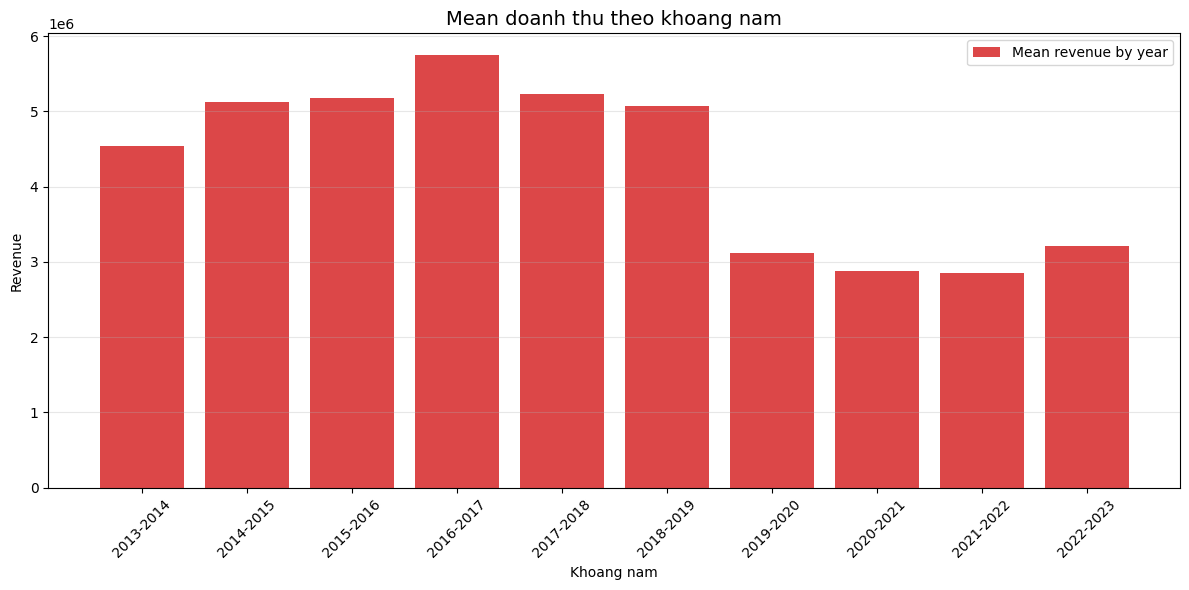

In [9]:
# Doanh thu trung bình theo năm
df_plot = df_sales.copy()
df_plot['date'] = pd.to_datetime(df_plot['date'])
df_plot = df_plot.sort_values('date').set_index('date')

yearly_mean = df_plot['revenue'].resample('YE').mean()
yearly_mean = yearly_mean[yearly_mean.index.year >= 2013]
years = yearly_mean.index.year
year_labels = [f"{y}-{y+1}" for y in years]

plt.figure(figsize=(12, 6))
plt.bar(range(len(yearly_mean)), yearly_mean.values, color='#d62728', alpha=0.85, label='Mean revenue by year')
plt.title('Mean doanh thu theo khoang nam', fontsize=14)
plt.xlabel('Khoang nam')
plt.ylabel('Revenue')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.xticks(range(len(year_labels)), year_labels, rotation=45)
plt.tight_layout()
plt.show()

Như vậy, ta có thể nhận định rằng doanh thu từ 2013 - 2019, doanh thu có xu hướng tăng triển lên và duy trì ở một mức nhất định, sau đó sụt giảm ở sau 2019, nhưng đến 2022 - 2023 lại bắt đầu tăng lại, có khẳ năng sau đó doanh thu có thể tăng lại. Vì vậy đây có thể có khả năng là một chu kỳ

In [10]:
# Kiểm tra tính chu kỳ của doanh thu bằng con số kiểm định



## 5. Tính mùa vụ
Sau khi xử lý được tính chu kỳ của doanh nghiệp, chúng tôi sẽ kiểm tra thêm tính mùa vụ qua từng khoảng thời gian dưới đây:
- **Year**
- **Quater**
- **Month**
- **Week**
- **Day**

### 5.1 Mùa vụ theo Năm

### 5.2 Mùa vụ theo Quý

### 5.3 Mùa vụ theo Tháng

### 5.4 Mùa vụ theo Tuần

### 5.5 Mùa vụ theo ngày

---
**Kết luận:**

---
**Notebooks tiếp theo:** [04_BASELINE_MODEL_.ipynb](04_BASELINE_MODEL_.ipynb) - Xây dựng mô hình cơ sở